In [9]:
import numpy as np
import input_parameters as parmt
import matplotlib.pyplot as plt
import matplotlib.colors
from epsilon_routines import epsilon_r, kramerskronig_im2re, interp_eps
from binning import gen_bin_centers, spherical_to_cartesian

%matplotlib ipympl

mElectron = 5.1099894e5
alpha = 1.0/137.03599908

#DarkELF
import sys
import os
sys.path.append(os.getcwd()+'/../DarkELF')
from darkelf import darkelf, targets

def elf(eps):
    return np.imag(eps)/((np.imag(eps))**2+np.real(eps)**2)

darkelf_gpaw = darkelf(target='Si', filename='Si_gpaw_noLFE.dat', )
darkelf_gpaw_lfe = darkelf(target='Si', filename='Si_gpaw_withLFE.dat')

 .... Loading files for Si
Loaded Si_gpaw_noLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, “Intensity of diffracted intensities,” in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554–595, https://onlinelibrary.wiley.com/doi/pdf/10.1107/97809553602060000
Loaded /home/meganhott/Research/dielectric_pyscf/../DarkELF/darkelf/../data/Si/Si_pDoS.dat for partial densi

### 8x8x8 with LFEs

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:302: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


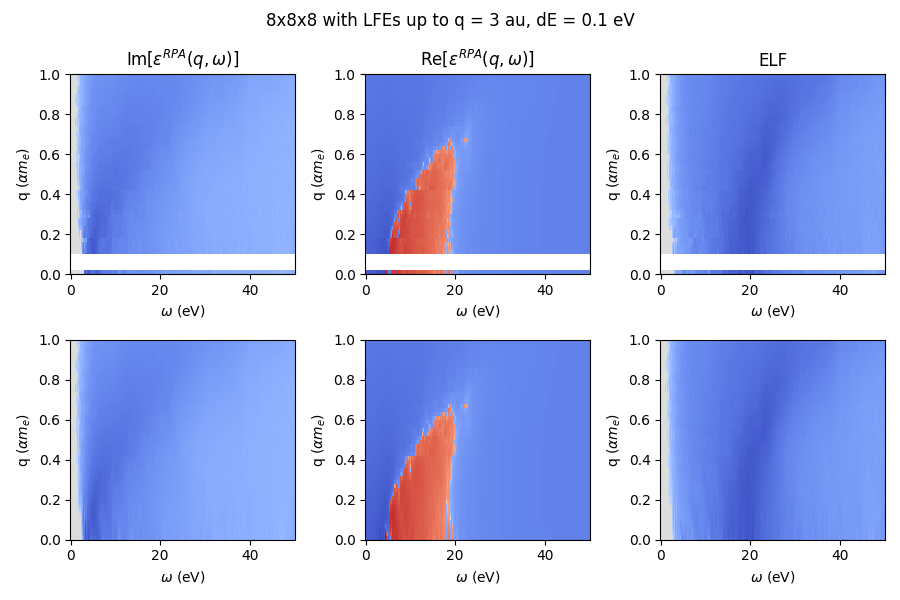

In [44]:
#dE = 0.1eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_8_bg1.10_3q_50E_lfe.npy')
bin_centers = gen_bin_centers(q_max=3)
eps_lfe = epsilon_r(bin_centers, binned_eps)
lfe_elf = elf(eps_lfe)

binned_eps_interp = interp_eps(bin_centers, binned_eps)
eps_lfe_interp = epsilon_r(bin_centers, binned_eps_interp)
lfe_interp_elf = elf(eps_lfe_interp)

q= np.arange(0.01,3.03,0.02) #alpha me
E = np.arange(0,50.1,0.1) #eV

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_lfe_interp))
re_max = np.max(np.real(eps_lfe_interp))
im_max = np.max(np.imag(eps_lfe_interp))
elf_max = np.max(lfe_interp_elf)
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,3, figsize=(9,6))

im0 = ax[(0,0)].pcolormesh(E, q, np.imag(eps_lfe), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(0,1)].pcolormesh(E, q, np.real(eps_lfe), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,2)].pcolormesh(E, q, lfe_elf, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))
im0 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_lfe_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(1,1)].pcolormesh(E, q, np.real(eps_lfe_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,2)].pcolormesh(E, q, lfe_interp_elf, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))

ax[(0,0)].set_title(r'Im[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,1)].set_title(r'Re[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,2)].set_title(r'ELF')

for i in [0,1]:
    for j in [0,1,2]:
        #ax[i].set_ylim([0,1])
        ax[(i,j)].set_xlabel(r'$\omega$ (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
        ax[(i,j)].set_ylim((0,1))
fig.suptitle('8x8x8 with LFEs up to q = 3 au, dE = 0.1 eV')
plt.tight_layout()

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:302: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


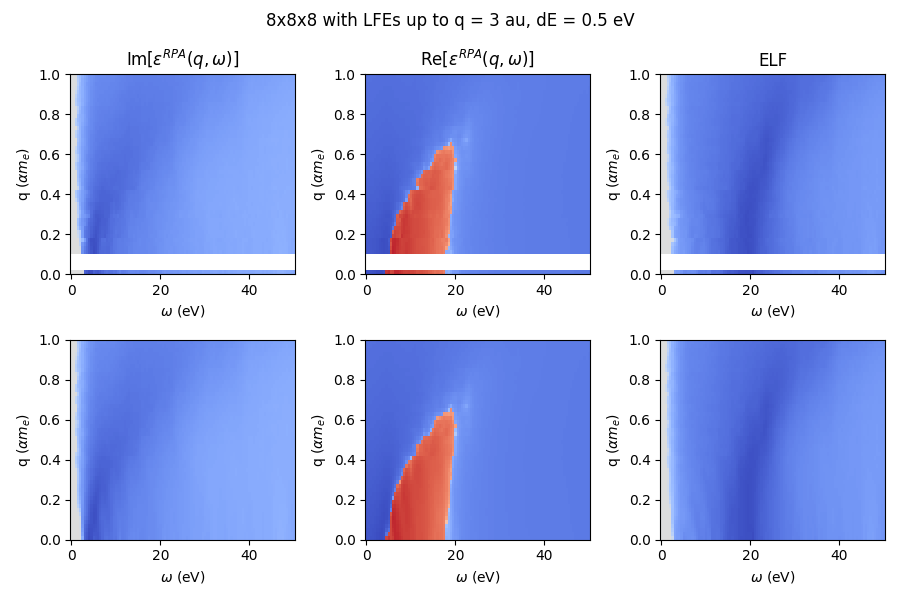

In [50]:
#dE = 0.5eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_8_bg1.10_3q_50E_0.5dE_lfe.npy')
bin_centers = gen_bin_centers(q_max=3)
eps_lfe = epsilon_r(bin_centers, binned_eps)
lfe_elf = elf(eps_lfe)

binned_eps_interp = interp_eps(bin_centers, binned_eps)
eps_lfe_interp = epsilon_r(bin_centers, binned_eps_interp)
lfe_interp_elf = elf(eps_lfe_interp)

q = np.arange(0.01,3.03,0.02) #alpha me
E = np.arange(0,50.5,0.5) #eV

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_lfe_interp))
re_max = np.max(np.real(eps_lfe_interp))
im_max = np.max(np.imag(eps_lfe_interp))
elf_max = np.max(lfe_interp_elf)
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,3, figsize=(9,6))

im0 = ax[(0,0)].pcolormesh(E, q, np.imag(eps_lfe), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(0,1)].pcolormesh(E, q, np.real(eps_lfe), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,2)].pcolormesh(E, q, lfe_elf, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))
im0 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_lfe_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(1,1)].pcolormesh(E, q, np.real(eps_lfe_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,2)].pcolormesh(E, q, lfe_interp_elf, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))

ax[(0,0)].set_title(r'Im[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,1)].set_title(r'Re[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,2)].set_title(r'ELF')

for i in [0,1]:
    for j in [0,1,2]:
        #ax[i].set_ylim([0,1])
        ax[(i,j)].set_xlabel(r'$\omega$ (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
        ax[(i,j)].set_ylim((0,1))
fig.suptitle('8x8x8 with LFEs up to q = 3 au, dE = 0.5 eV')
plt.tight_layout()

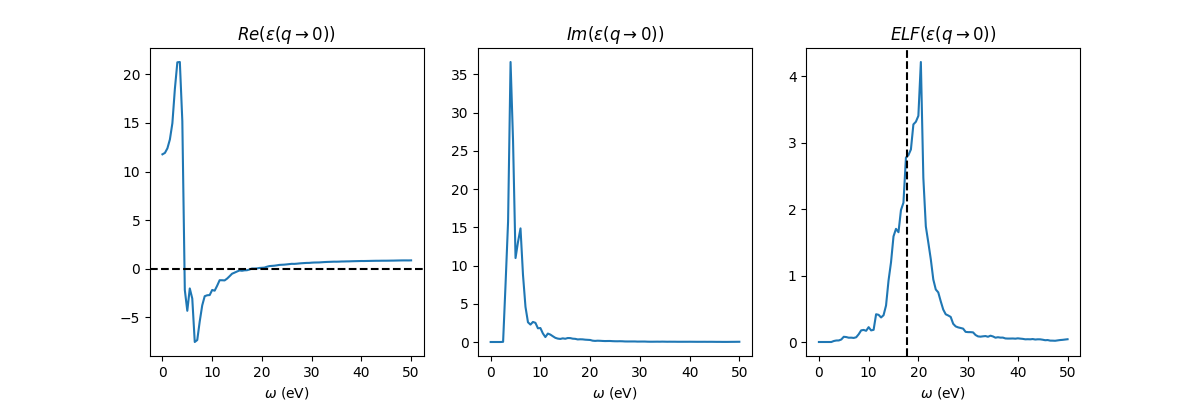

In [57]:
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(E, np.real(eps_lfe_interp[0]))
ax[0].axhline(0, color='k', linestyle='--')
ax[0].set_title(r'$Re(\epsilon(q\rightarrow 0))$')

ax[1].plot(E, np.imag(eps_lfe_interp[0]))
#ax[1].axhline(0, color='k', linestyle='--')
ax[1].set_title(r'$Im(\epsilon(q\rightarrow 0))$')

ax[2].plot(E, lfe_interp_elf[0])
ax[2].axvline(17.75, color='k', linestyle='--')
ax[2].set_title(r'$ELF(\epsilon(q\rightarrow 0))$')

for i in [0,1,2]:
    ax[i].set_xlabel(r'$\omega$ (eV)')

### 6x6x6 with LFEs

In [12]:
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_3q_50E_lfe.npy')
bin_centers = gen_bin_centers(q_max=3)
eps_lfe = epsilon_r(bin_centers, binned_eps)
lfe_elf = elf(eps_lfe)

binned_eps_interp = interp_eps(bin_centers, binned_eps)
eps_lfe_interp = epsilon_r(bin_centers, binned_eps_interp)
lfe_interp_elf = elf(eps_lfe_interp)

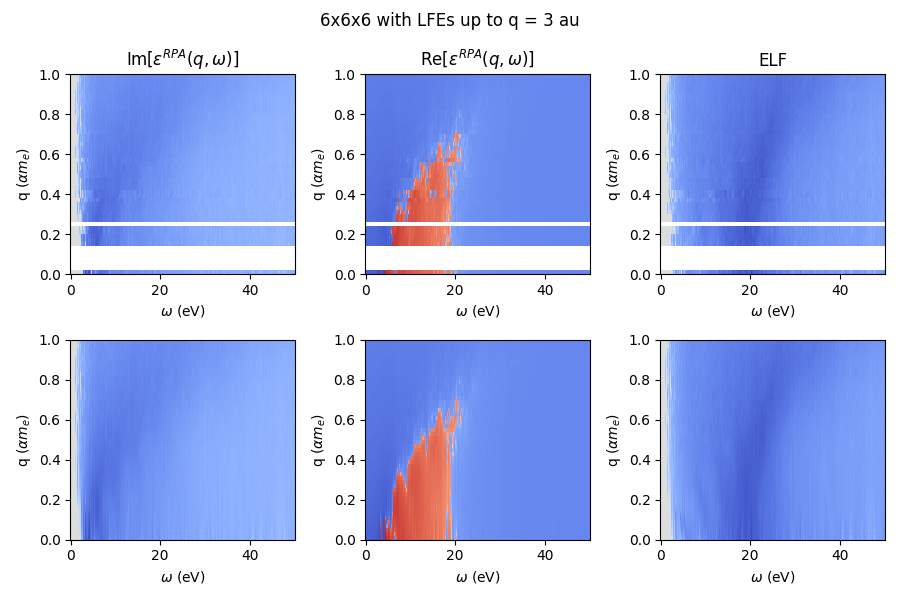

In [13]:
q = np.arange(0.01,3.03,0.02) #alpha me
E = np.linspace(0, 50, 501) #eV

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_lfe_interp))
re_max = np.max(np.real(eps_lfe_interp))
im_max = np.max(np.imag(eps_lfe_interp))
elf_max = np.max(lfe_interp_elf)
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,3, figsize=(9,6))

im0 = ax[(0,0)].pcolormesh(E, q, np.imag(eps_lfe), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(0,1)].pcolormesh(E, q, np.real(eps_lfe), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,2)].pcolormesh(E, q, lfe_elf, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))
im0 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_lfe_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(1,1)].pcolormesh(E, q, np.real(eps_lfe_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,2)].pcolormesh(E, q, lfe_interp_elf, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))

ax[(0,0)].set_title(r'Im[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,1)].set_title(r'Re[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,2)].set_title(r'ELF')

for i in [0,1]:
    for j in [0,1,2]:
        #ax[i].set_ylim([0,1])
        ax[(i,j)].set_xlabel(r'$\omega$ (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
        ax[(i,j)].set_ylim((0,1))
fig.suptitle('6x6x6 with LFEs up to q = 3 au')
plt.tight_layout()

### Interpolated 8x8x8 up to 5ame for Megan and Hailin

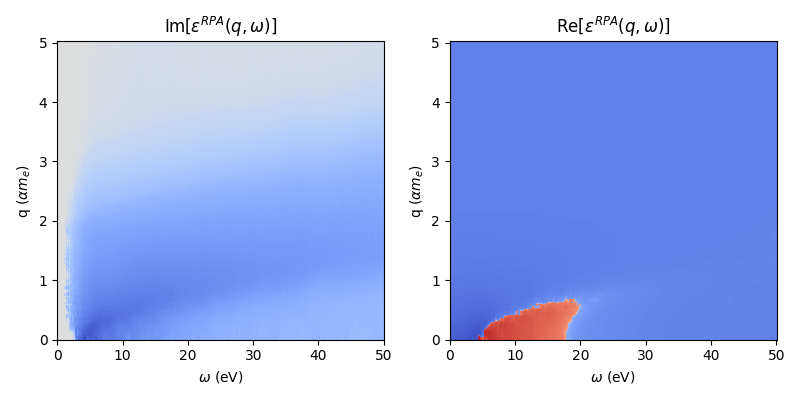

In [16]:
q = np.linspace(0.01, 5.01, 251) #alpha me
E = np.linspace(0, 50, 501) #eV

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_8_bg1.10_5q_50E.npy') #8x8x8
bin_centers = gen_bin_centers(q_max=5)
int_binned_eps = interp_eps(bin_centers, binned_eps)

eps_8 = epsilon_r(bin_centers, binned_eps)
eps_8_interp = epsilon_r(bin_centers, int_binned_eps) #interpolated with LinearNDInterpolator from scipy

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_8_interp))
re_max = np.max(np.real(eps_8_interp))
im_max = np.max(np.imag(eps_8_interp))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(1,2, figsize=(8,4))

im0 = ax[0].pcolormesh(E, q, np.imag(eps_8_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[1].pcolormesh(E, q, np.real(eps_8_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'Im[$\epsilon^{RPA}(q, \omega)$]')
ax[1].set_title(r'Re[$\epsilon^{RPA}(q, \omega)$]')

for i in [0,1]:
    #ax[i].set_ylim([0,1])
    ax[i].set_xlabel(r'$\omega$ (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

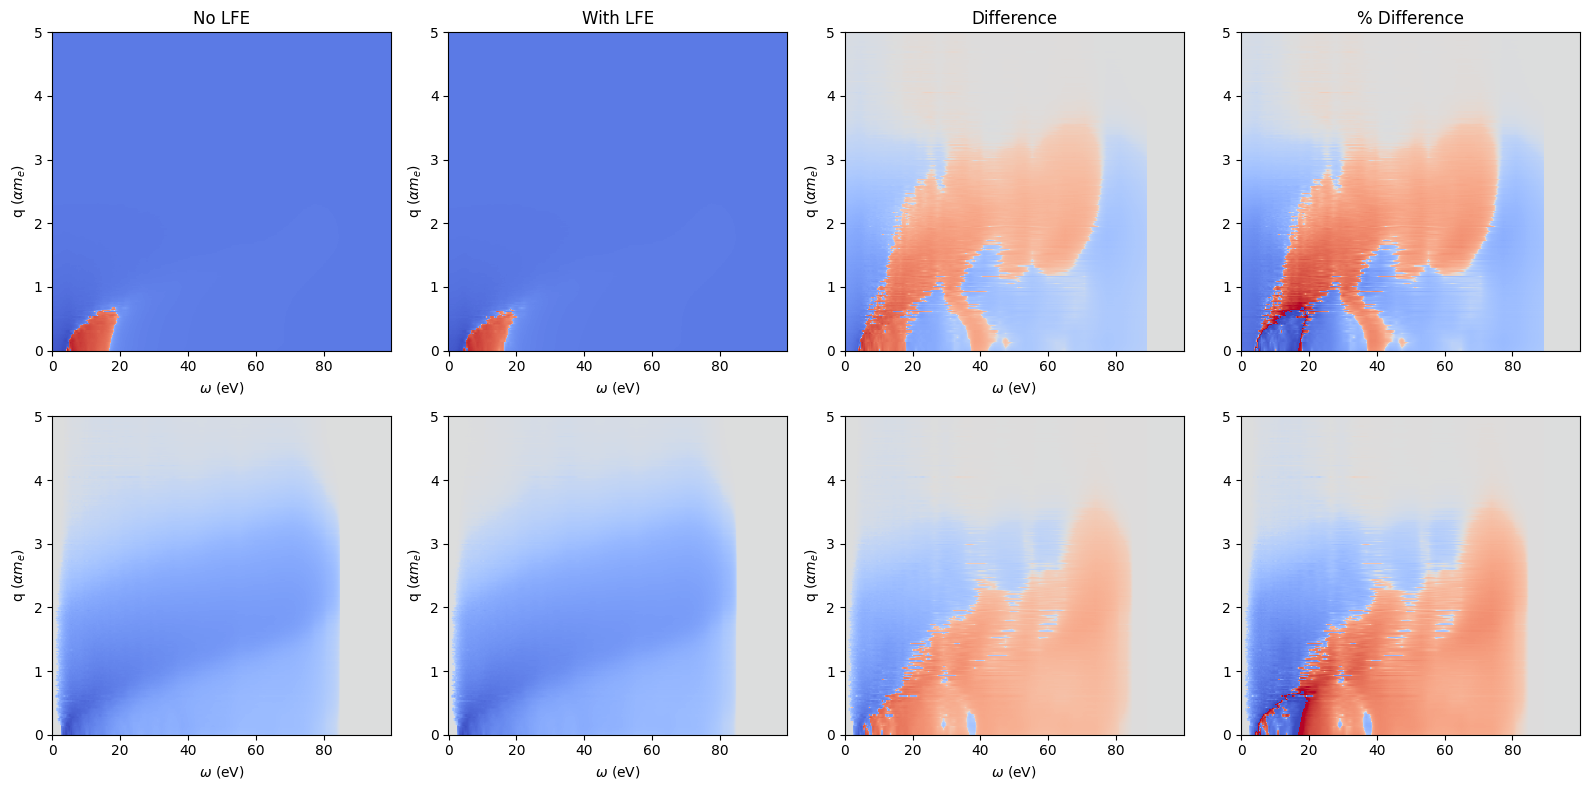

In [61]:
q = np.arange(0.01, 5, parmt.dq) #alpha me
E = np.arange(0, 100, parmt.dE) #eV

nolfe_re = darkelf_gpaw.eps1(E, q*alpha*mElectron)
nolfe_im = darkelf_gpaw.eps2(E, q*alpha*mElectron)
lfe_re = darkelf_gpaw_lfe.eps1(E, q*alpha*mElectron)
lfe_im = darkelf_gpaw_lfe.eps2(E, q*alpha*mElectron)

dif_re = (nolfe_re - lfe_re)
dif_im = (nolfe_im - lfe_im)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.concatenate([nolfe_re, lfe_re]))
re_max = np.max(np.concatenate([nolfe_re, lfe_re]))
im_max = np.max(np.concatenate([nolfe_im, lfe_im]))
re_max = max(-1*re_min, re_max)


fig, ax = plt.subplots(2,4, figsize=(16,8))

im0 = ax[(0,0)].pcolormesh(E, q, nolfe_re, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, nolfe_im, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im2 = ax[(0,1)].pcolormesh(E, q, lfe_re, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, lfe_im, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im4 = ax[(0,2)].pcolormesh(E, q, dif_re, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im5 = ax[(1,2)].pcolormesh(E, q, dif_im, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im4 = ax[(0,3)].pcolormesh(E, q, dif_re/nolfe_re, cmap=c, norm=matplotlib.colors.SymLogNorm(1e-4, vmin=-1, vmax=1))
im5 = ax[(1,3)].pcolormesh(E, q, dif_im/nolfe_re, cmap=c, norm=matplotlib.colors.SymLogNorm(1e-4, vmin=-1, vmax=1))


ax[(0,0)].set_title('No LFE')
ax[(0,1)].set_title('With LFE')
ax[(0,2)].set_title('Difference')
ax[(0,3)].set_title('% Difference')

for i in [0,1]:
    for j in [0,1,2,3]:
        ax[(i,j)].set_xlabel(r'$\omega$ (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

### GPAW and Interpolated RPA Comparison 

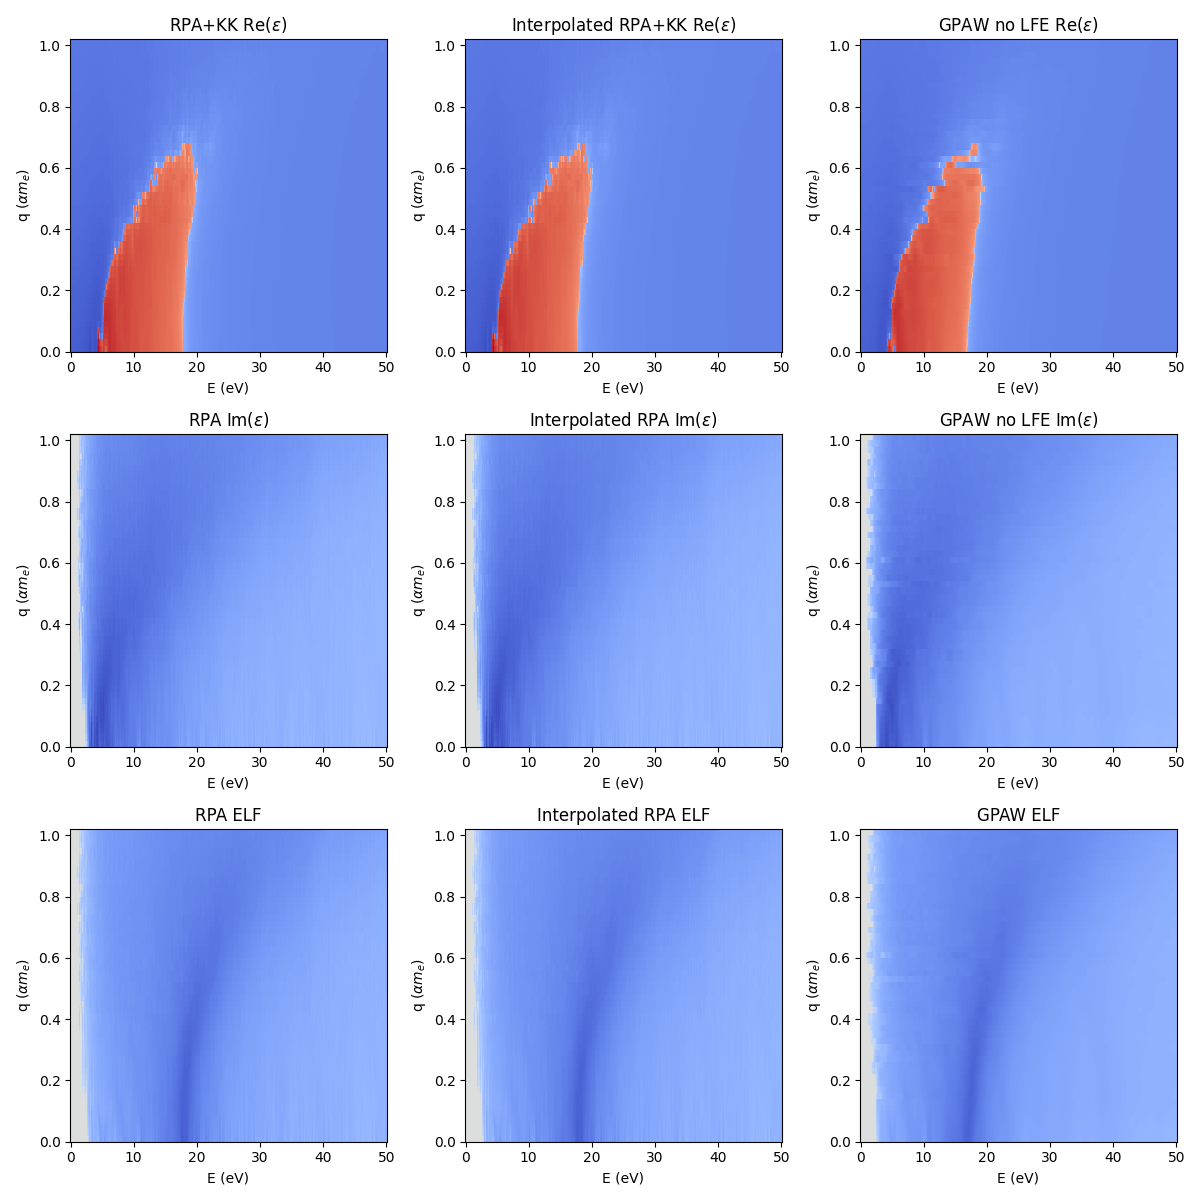

In [17]:
q = np.arange(0.01, 1+1.5*0.02, 0.02) #alpha me
E = np.arange(0, 50+0.1, 0.1) #eV

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_8_bg1.10_1q_50E.npy') #8x8x8
bin_centers = gen_bin_centers(q_max=1)
int_binned_eps = interp_eps(bin_centers, binned_eps)

eps_8 = epsilon_r(bin_centers, binned_eps)
eps_8_interp = epsilon_r(bin_centers, int_binned_eps) #interpolated with LinearNDInterpolator from scipy

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_8[np.invert(np.isnan(eps_8))]))
re_max = np.max(np.real(eps_8[np.invert(np.isnan(eps_8))]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(3,3, figsize=(12,12))

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps_8), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_8), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im6 = ax[(2,0)].pcolormesh(E, q, elf(eps_8), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[(0,1)].pcolormesh(E, q, np.real(eps_8_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.imag(eps_8_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im7 = ax[(2,1)].pcolormesh(E, q, elf(eps_8_interp), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im4 = ax[(0,2)].pcolormesh(E, q, darkelf_gpaw.eps1(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im5 = ax[(1,2)].pcolormesh(E, q, darkelf_gpaw.eps2(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im8 = ax[(2,2)].pcolormesh(E, q, elf(darkelf_gpaw.eps1(E, q*alpha*mElectron) + 1j*darkelf_gpaw.eps2(E, q*alpha*mElectron)), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[(0,0)].set_title(r'RPA+KK Re($\epsilon$)')
ax[(1,0)].set_title(r'RPA Im($\epsilon$)')
ax[(2,0)].set_title('RPA ELF')

ax[(0,1)].set_title(r'Interpolated RPA+KK Re($\epsilon$)')
ax[(1,1)].set_title(r'Interpolated RPA Im($\epsilon$)')
ax[(2,1)].set_title('Interpolated RPA ELF')

ax[(0,2)].set_title(r'GPAW no LFE Re($\epsilon$)')
ax[(1,2)].set_title(r'GPAW no LFE Im($\epsilon$)')
ax[(2,2)].set_title('GPAW ELF')

for i in [0,1,2]:
    for j in [0,1,2]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

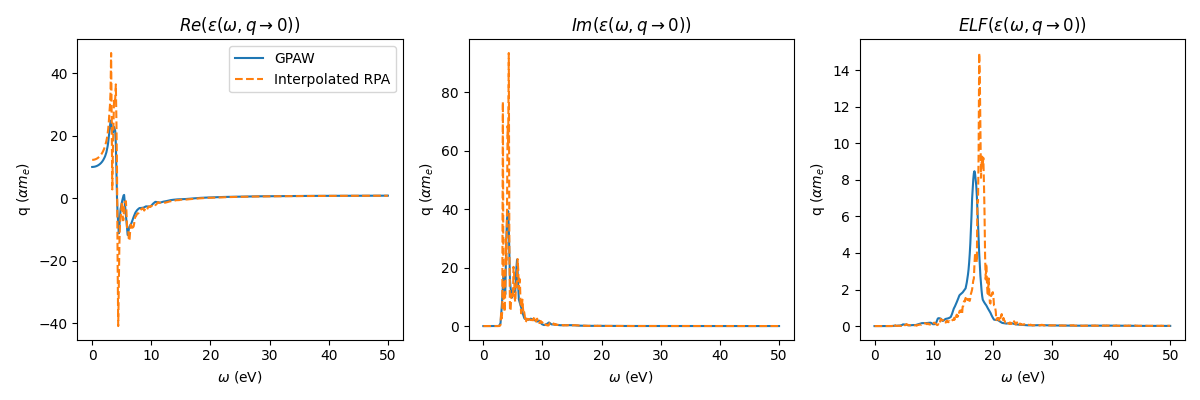

In [24]:
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(E, darkelf_gpaw.eps1(E, q*alpha*mElectron)[0], label='GPAW')
#ax[0].plot(E, np.real(eps_8[0]), label='RPA')
ax[0].plot(E, np.real(eps_8_interp[0]), '--', label='Interpolated RPA')
ax[0].set_title(r'$Re(\epsilon(\omega, q\rightarrow 0))$')
ax[0].legend()

ax[1].plot(E, darkelf_gpaw.eps2(E, q*alpha*mElectron)[0], label='GPAW')
#ax[1].plot(E, np.imag(eps_8[0]), label='RPA')
ax[1].plot(E, np.imag(eps_8_interp[0]), '--', label='Interpolated RPA')
ax[1].set_title(r'$Im(\epsilon(\omega, q\rightarrow 0))$')

ax[2].plot(E, elf(darkelf_gpaw.eps1(E, q*alpha*mElectron) + 1j*darkelf_gpaw.eps2(E, q*alpha*mElectron))[0], label='GPAW')
#ax[2].plot(E, elf(eps_8)[0], label='RPA')
ax[2].plot(E, elf(eps_8_interp)[0], '--', label='Interpolated RPA')
ax[2].set_title(r'$ELF(\epsilon(\omega, q\rightarrow 0))$')

for i in [0,1,2]:
    ax[i].set_xlabel(r'$\omega$ (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

In [38]:
#RPA
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_200E_old.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_46_bg1.10_1q_50E_old.npy') #4x4x4 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps_46 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_68_bg1.10_1q_50E_old.npy') #6x6x6 -> 8x8x8
bin_centers = gen_bin_centers(q_max=1)
eps_68 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_8_bg1.10_1q_50E_old.npy') #8x8x8 -> 8x8x8
bin_centers = gen_bin_centers(q_max=1)
eps_8 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_5q_50E_old.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=5)
eps_6_5q = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvdz_pbe_6_bg1.10_1q_50E_tz_6_old.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps_6_dz = epsilon_r(bin_centers, binned_eps)

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:258: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


### Original $\text{Re}(\epsilon^{\text{RPA}})$
- Need to use Kramers-Kronig relations to obtain $\text{Re}(\epsilon^{\text{RPA}})$ from $\text{Im}(\epsilon^{\text{RPA}})$ instead of directly calculating

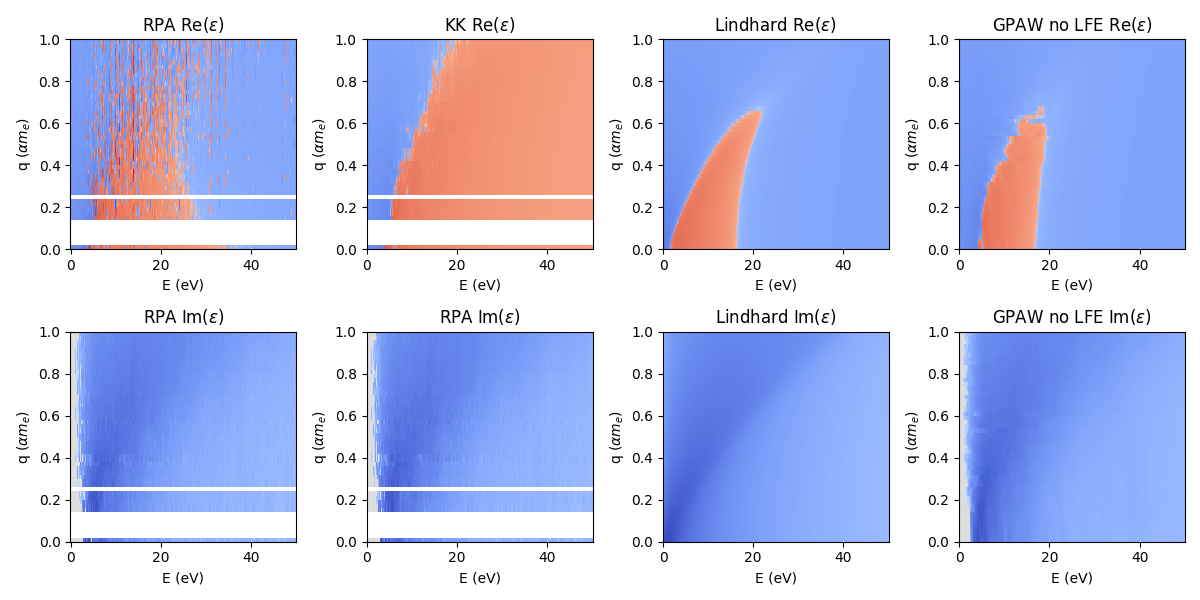

In [29]:
#RPA
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_200E_old.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps = epsilon_r(bin_centers, binned_eps)[:-1]

q = np.arange(0.01, 1, 0.02) #alpha me
E = np.arange(0, 200+0.1, 0.1) #eV

#Lindhard model
VCell = 5.209e-9
nValence = 8
MCell = 52322355000.0
mElectron = 5.1099894e5
alpha = 1.0/137.03599908

E_mesh, q_mesh = np.meshgrid(E, q)

def Lindhard(om, q, fp): #energy, q, 
    q = q*alpha*mElectron #convert q from ame to eV
    def plog(x):
        return np.log(np.abs(x)) + 1j*np.angle(x)
    ne = nValence/VCell
    kF = (3*np.pi**2*ne)**(1./3.)
    omp = np.sqrt(4*np.pi*alpha*ne/mElectron)
    vF = kF/mElectron
    Gp = fp*omp
    Qp = q/(2*kF) + (om + 1j*Gp)/(q*vF)
    Qm = q/(2*kF) - (om + 1j*Gp)/(q*vF)
    factor1 = 3*(omp**2)/(q**2)/(vF**2)
    factor2 = 0.5 + kF/(4*q)*(1-Qm**2)*plog((Qm+1)/(Qm-1)) + kF/(4*q)*(1-Qp**2)*plog((Qp+1)/(Qp-1))
    return 1 + factor1*factor2

eps_l = Lindhard(E_mesh, q_mesh, 0.1)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.concatenate([np.real(eps[np.invert(np.isnan(eps))]), np.real(eps_l[np.invert(np.isnan(eps_l))])]))
re_max = np.max(np.concatenate([np.real(eps[np.invert(np.isnan(eps))]), np.real(eps_l[np.invert(np.isnan(eps_l))])]))
im_min = np.min(np.concatenate([np.imag(eps[np.invert(np.isnan(eps))]), np.imag(eps_l[np.invert(np.isnan(eps_l))])]))
im_max = np.max(np.concatenate([np.imag(eps[np.invert(np.isnan(eps))]), np.imag(eps_l[np.invert(np.isnan(eps_l))])]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,4, figsize=(12,6))

im0 = ax[(0,0)].pcolormesh(E[:501], q, np.real(eps[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E[:501], q, 10*np.imag(eps[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im2 = ax[(0,1)].pcolormesh(E[:501], q, kramerskronig_im2re(10*np.imag(eps[:,:501])), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E[:501], q, 10*np.imag(eps[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im4 = ax[(0,2)].pcolormesh(E[:501], q, np.real(eps_l[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im5 = ax[(1,2)].pcolormesh(E[:501], q, np.imag(eps_l[:,:501]), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im6 = ax[(0,3)].pcolormesh(E[:501], q, darkelf_gpaw.eps1(E[:501], q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im7 = ax[(1,3)].pcolormesh(E[:501], q, darkelf_gpaw.eps2(E[:501], q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
"""
im0 = ax[(0,0)].imshow(np.real(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max), origin='lower')
"""
#fig.colorbar(im0, ax=ax[(0,0)])
#fig.colorbar(im1, ax=ax[(1,0)])
ax[(0,0)].set_title(r'RPA Re($\epsilon$)')
ax[(1,0)].set_title(r'RPA Im($\epsilon$)')
#ax[(1,0)].axvline(x=1.12, ymin=0, ymax=1, color='k', linestyle='--')
#fig.colorbar(im2, ax=ax[(0,1)])
#fig.colorbar(im3, ax=ax[(1,1)])
ax[(0,1)].set_title(r'KK Re($\epsilon$)')
ax[(1,1)].set_title(r'RPA Im($\epsilon$)')
ax[(0,2)].set_title(r'Lindhard Re($\epsilon$)')
ax[(1,2)].set_title(r'Lindhard Im($\epsilon$)')
#fig.colorbar(im4, ax=ax[(0,2)])
#fig.colorbar(im5, ax=ax[(1,2)])
ax[(0,3)].set_title(r'GPAW no LFE Re($\epsilon$)')
ax[(1,3)].set_title(r'GPAW no LFE Im($\epsilon$)')

for i in [0,1]:
    for j in [0,1,2,3]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

### Testing Different k-grids
- Using different $k$ and $k'$ grids gives us data for small q bins, but it seems to be inaccurate anyway. It's better to use same-sized $k$, $k'$ and interpolate the missing bins

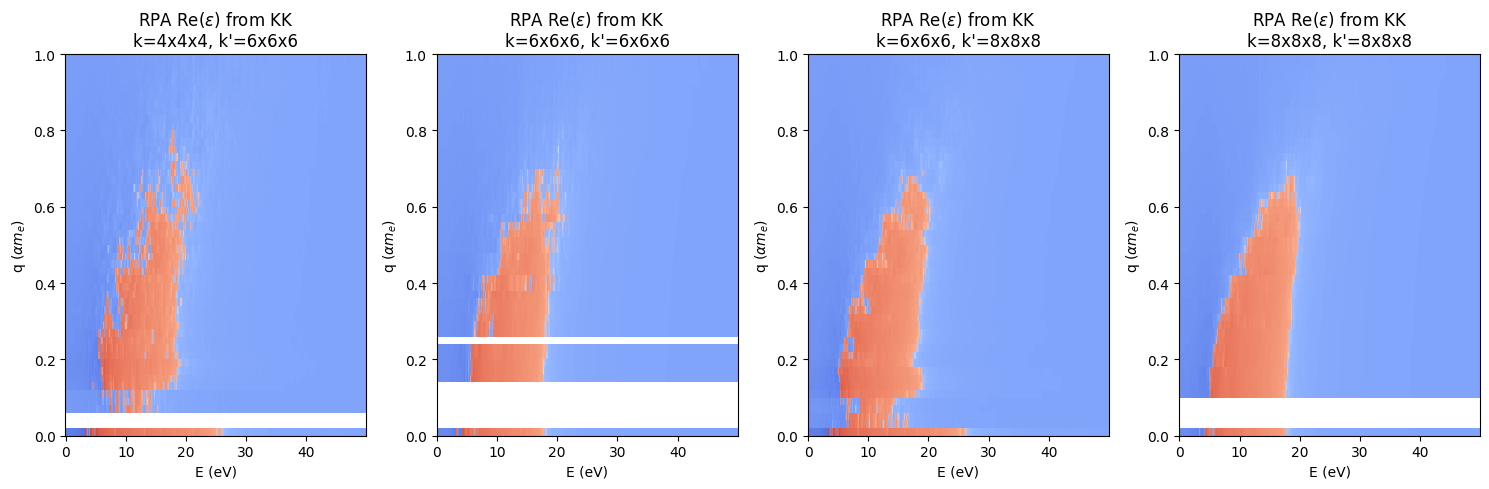

In [17]:
def kk_2d(eps, E, n_E, corr=False):
    eps_im = np.imag(eps)
    eps_re = np.zeros((eps_im.shape[0], n_E))
    for n, En in enumerate(E[:n_E]):
        E_pv = np.delete(E, n) #removes Ei = En for principal value
        eps_im_pv = np.delete(eps_im, n, axis=1)

        eps_re[:,n] = 2/np.pi*parmt.dE*(np.sum(E_pv[None,:] * eps_im_pv / (E_pv[None,:]**2 - En**2), axis=1) - 0.5*(E_pv[None,0]*eps_im_pv[:,0]/(E_pv[None,0]**2-En**2) + E_pv[None,-1]*eps_im_pv[:,-1]/(E_pv[None,-1]**2-En**2))) #trapezoid rule
    if corr:
        eps_re = eps_re*10 #correction factor is 1/parmt.dE = 10, not 4pi
    return eps_re + 1

#Kramers-Kronig RPA
q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 200+parmt.dE, parmt.dE) #eV

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_200E_old.npy') #6x6x6 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps = epsilon_r(bin_centers, binned_eps)[:-1] #last r bin is inaccurate for old versions

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_46_bg1.10_1q_50E_old.npy') #4x4x4 -> 6x6x6
bin_centers = gen_bin_centers(q_max=1)
eps_46 = epsilon_r(bin_centers, binned_eps)[:-1]

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_68_bg1.10_1q_50E_old.npy') #6x6x6 -> 8x8x8
bin_centers = gen_bin_centers(q_max=1)
eps_68 = epsilon_r(bin_centers, binned_eps)[:-1]

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_8_bg1.10_1q_50E_old.npy') #8x8x8 -> 8x8x8
bin_centers = gen_bin_centers(q_max=1)
eps_8 = epsilon_r(bin_centers, binned_eps)[:-1]

eps_kk_re_50 = kk_2d(eps[:,:501], E[:501], 500, corr=True) #only using data up to 50eV in KK
eps_kk_re_46 = kk_2d(eps_46, E[:501], 500, corr=True) 
eps_kk_re_68 = kk_2d(eps_68, E[:501], 500, corr=True) 
eps_kk_re_8 = kk_2d(eps_8, E[:501], 500, corr=True)

fig, ax = plt.subplots(1, 4, figsize=(15,5))
im0 = ax[0].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_46, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[1].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_50, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[2].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_68, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[3].pcolormesh(E[:int(50/parmt.dE)], q, eps_kk_re_8, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[0].set_title(r'RPA Re($\epsilon$) from KK'+'\n'+"k=4x4x4, k'=6x6x6")
ax[1].set_title(r'RPA Re($\epsilon$) from KK'+'\n'+"k=6x6x6, k'=6x6x6")
ax[2].set_title(r'RPA Re($\epsilon$) from KK'+'\n'+"k=6x6x6, k'=8x8x8")
ax[3].set_title(r'RPA Re($\epsilon$) from KK'+'\n'+"k=8x8x8, k'=8x8x8")
for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

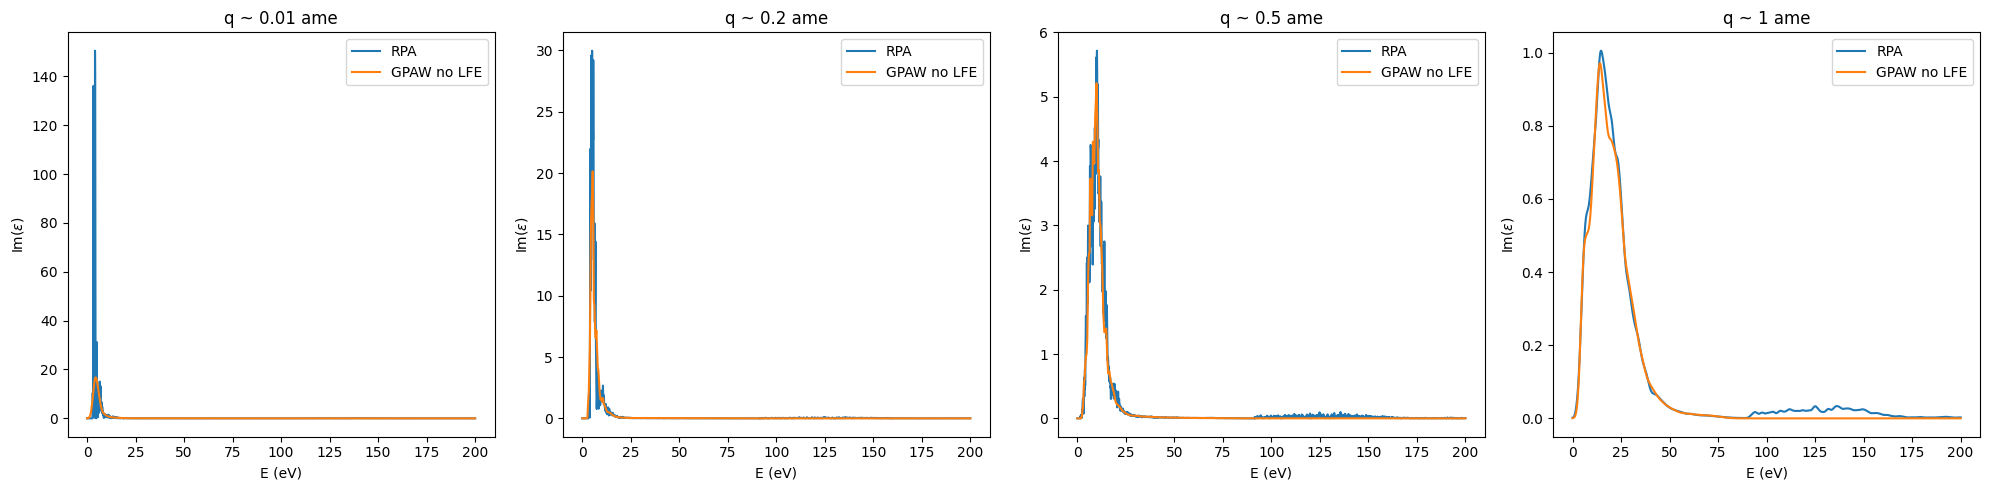

In [50]:
#Im plots
from scipy.ndimage import gaussian_filter1d

#Nonlinear factor to make RPA match GPAW and Lindhard

fig, ax = plt.subplots(1,4, figsize=(20,5))
ax[0].plot(E, 10*np.imag(eps[0,:]), label='RPA')
#ax[0].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[0,:]),10), label='Smoothed RPA')
ax[0].plot(E, gaussian_filter1d(darkelf_gpaw.eps2(E, 0.01*alpha*mElectron),10), label='GPAW no LFE')
#ax[0].plot(E, np.imag(eps_l[0,:]), label='Lindhard')
ax[0].set_title('q ~ 0.01 ame')
ax[0].legend()

ax[1].plot(E, 10*np.imag(eps[10,:]), label='RPA')
#ax[1].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[10,:]),10), label='Smoothed RPA')
ax[1].plot(E, darkelf_gpaw.eps2(E, 0.2*alpha*mElectron), label='GPAW no LFE')
#ax[1].plot(E, np.imag(eps_l[25,:]), label='Lindhard')
ax[1].set_title('q ~ 0.2 ame')
ax[1].legend()

ax[2].plot(E, 10*np.imag(eps[25,:]), label='RPA')
#ax[2].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[25,:]),10), label='Smoothed RPA')
ax[2].plot(E, darkelf_gpaw.eps2(E, 0.5*alpha*mElectron), label='GPAW no LFE')
#ax[1].plot(E, np.imag(eps_l[25,:]), label='Lindhard')
ax[2].set_title('q ~ 0.5 ame')
ax[2].legend()

ax[3].plot(E, 10*gaussian_filter1d(np.imag(eps[-1,:]),10), label='RPA')
#ax[3].plot(E, 4*np.pi*gaussian_filter1d(np.imag(eps[-1,:]),10), label='Smoothed RPA')
ax[3].plot(E, gaussian_filter1d(darkelf_gpaw.eps2(E, 1*alpha*mElectron),10), label='GPAW no LFE')
#ax[2].plot(E, np.imag(eps_l[-1,:]), label='Lindhard')
ax[3].set_title('q ~ 1 ame')
ax[3].legend()

for i in [0,1,2,3]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'Im($\epsilon)$')
plt.tight_layout()
plt.show()


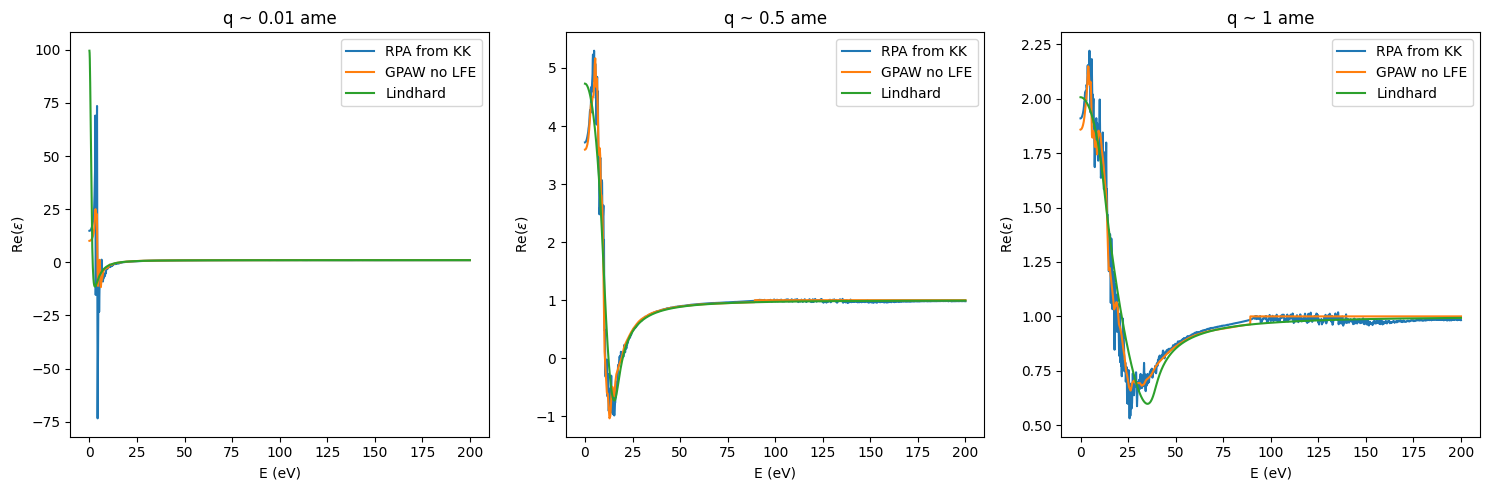

In [52]:
#Re plots

fig, ax = plt.subplots(1,3, figsize=(15,5))
#ax[0].plot(E, gaussian_filter1d(np.real(eps[0,:]),10), label='Smoothed RPA')
ax[0].plot(E, eps_kk_re[0], label='RPA from KK')
ax[0].plot(E, darkelf_gpaw.eps1(E, 0.01*alpha*mElectron), label='GPAW no LFE')
ax[0].plot(E, np.real(eps_l[0,:]), label='Lindhard')
ax[0].set_title('q ~ 0.01 ame')
ax[0].legend()

#ax[1].plot(E, gaussian_filter1d(np.real(eps[25,:]),10), label='Smoothed RPA')
ax[1].plot(E, eps_kk_re[25], label='RPA from KK') 
ax[1].plot(E, darkelf_gpaw.eps1(E, 0.5*alpha*mElectron), label='GPAW no LFE')
ax[1].plot(E, np.real(eps_l[25,:]), label='Lindhard')
ax[1].set_title('q ~ 0.5 ame')
ax[1].legend()

#ax[2].plot(E, gaussian_filter1d(np.real(eps[-1,:]),10), label='Smoothed RPA')
ax[2].plot(E, eps_kk_re[-1], label='RPA from KK')
ax[2].plot(E, darkelf_gpaw.eps1(E, 1*alpha*mElectron), label='GPAW no LFE')
ax[2].plot(E, np.real(eps_l[-1,:]), label='Lindhard')
ax[2].set_title('q ~ 1 ame')
ax[2].legend()

for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'Re($\epsilon)$')
plt.tight_layout()
plt.show()

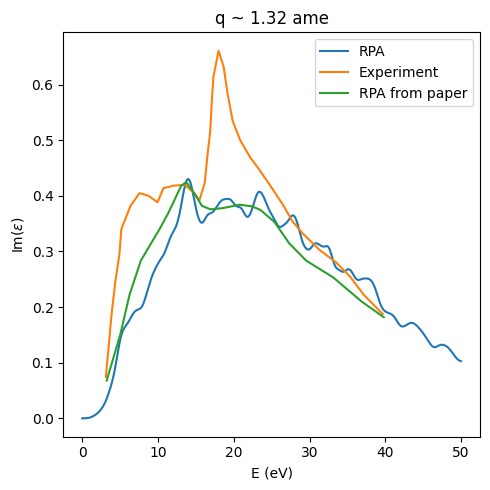

In [53]:
#Compare to experiment
#eps_6_5q
#eps_6_5q_kk = kk_2d(eps_6_5q, E, 501, corr=True)
exp_eps = np.genfromtxt('test_resources/exp_data_im.csv', delimiter=', ')
exp_rpa = np.genfromtxt('test_resources/exp_rpa_no_lfe.csv', delimiter=', ')

fig, ax = plt.subplots(1, figsize=(5,5))
ax.plot(E[:501], 10*gaussian_filter1d(np.imag(eps_6_5q[int(1.32/parmt.dq)]), 5), label='RPA')
ax.plot(exp_eps[:,0], exp_eps[:,1], label='Experiment')
ax.plot(exp_rpa[:,0], exp_rpa[:,1], label='RPA from paper')
#ax.plot(E, darkelf_gpaw.eps1(E, 0.01*alpha*mElectron), label='GPAW no LFE')
#ax.plot(E, np.real(eps_l[0,:]), label='Lindhard')
ax.set_title('q ~ 1.32 ame')
ax.legend()

ax.set_xlabel('E (eV)')
ax.set_ylabel(r'Im($\epsilon)$')
plt.tight_layout()

### Testing different $k'$ offset directions
- This does not seem to affect plasmon location

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:258: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


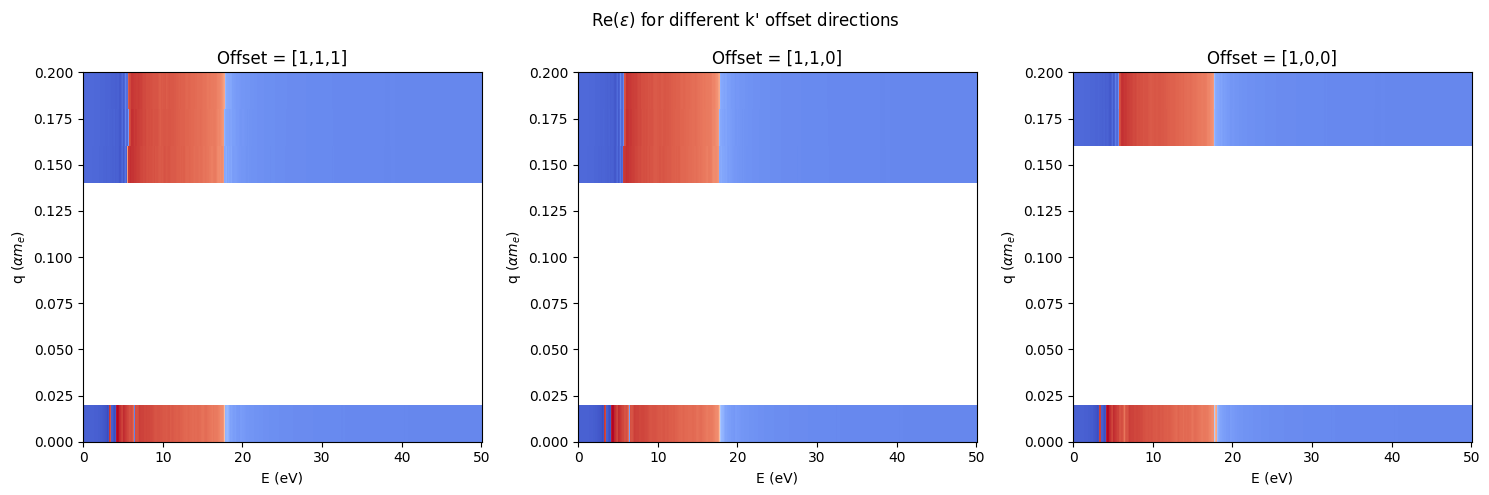

In [54]:
#k' offset in different directions
q = np.arange(0.01, 0.2, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_0.2q_50E_tz_6_offset111_old.npy')
bin_centers = gen_bin_centers(q_max=0.2)
eps_111 = epsilon_r(bin_centers, binned_eps)
eps_111_kk = kk_2d(eps_111, E, E.shape[0], corr=True)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_0.2q_50E_tz_6_offset110_old.npy')
bin_centers = gen_bin_centers(q_max=0.2)
eps_110 = epsilon_r(bin_centers, binned_eps)
eps_110_kk = kk_2d(eps_110, E, E.shape[0], corr=True)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_0.2q_50E_tz_6_offset100_old.npy')
bin_centers = gen_bin_centers(q_max=0.2)
eps_100 = epsilon_r(bin_centers, binned_eps)
eps_100_kk = kk_2d(eps_100, E, E.shape[0], corr=True)

c = 'coolwarm_r'
th = 1e-4
re_min_offset = np.min(np.concatenate([eps_111_kk[np.invert(np.isnan(eps_111_kk))], eps_110_kk[np.invert(np.isnan(eps_110_kk))], eps_100_kk[np.invert(np.isnan(eps_100_kk))]]))
re_max_offset = np.max(np.concatenate([eps_111_kk[np.invert(np.isnan(eps_111_kk))], eps_110_kk[np.invert(np.isnan(eps_110_kk))], eps_100_kk[np.invert(np.isnan(eps_100_kk))]]))
re_max_offset = np.max([re_max_offset, -re_min_offset])

fig, ax = plt.subplots(1, 3, figsize=(15,5))
im0 = ax[0].pcolormesh(E, q, eps_111_kk, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max_offset, vmax=re_max_offset))
im1 = ax[1].pcolormesh(E, q, eps_110_kk, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max_offset, vmax=re_max_offset))
im2 = ax[2].pcolormesh(E, q, eps_100_kk, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max_offset, vmax=re_max_offset))

ax[0].set_title('Offset = [1,1,1]')
ax[1].set_title('Offset = [1,1,0]')
ax[2].set_title('Offset = [1,0,0]')
fig.suptitle(r"Re($\epsilon$) for different k' offset directions")
for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

### Testing Different Bandgaps
- Small bandgap difference does not affect plasmon frequency
- Significantly smaller bandgap does reduce plasmon frequency

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:302: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


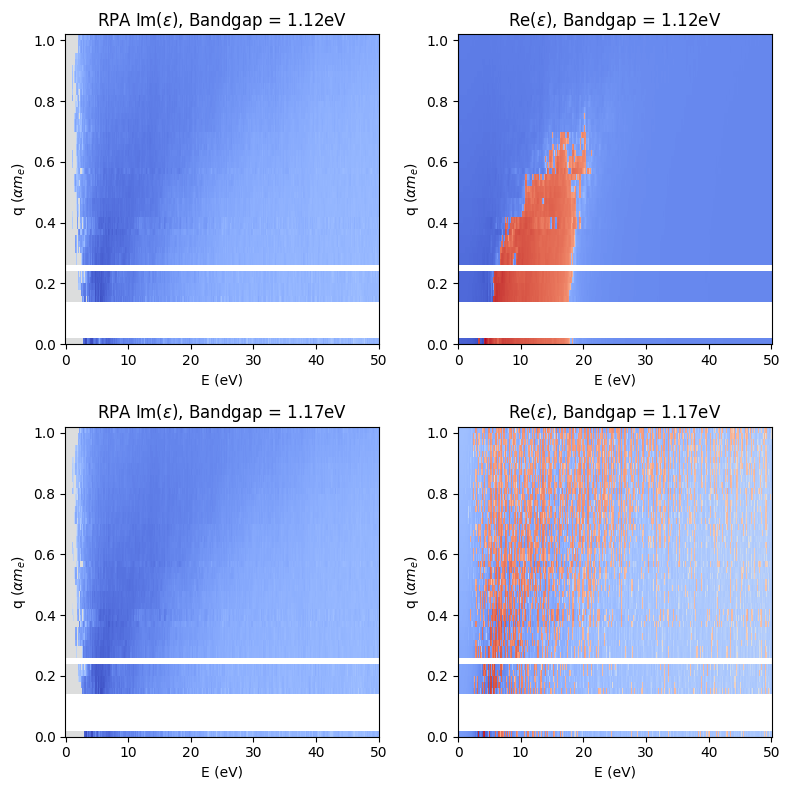

In [18]:
#Testing different bandgaps
q = np.arange(0.01, 1.03, 0.02) #alpha me
E = np.arange(0, 50.1, 0.1) #eV

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E.npy') #6x6x6 -> 6x6x6
binned_eps = (np.real(binned_eps)-1)*10/4/np.pi+1 + 1j*np.imag(binned_eps)*10/4/np.pi
bin_centers = gen_bin_centers(q_max=1)
eps_112 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.17_1q_50E.npy') #6x6x6 -> 6x6x6
binned_eps = (np.real(binned_eps)-1)*10/4/np.pi+1 + 1j*np.imag(binned_eps)*10/4/np.pi
bin_centers = gen_bin_centers(q_max=1)
eps_117 = epsilon_r(bin_centers, binned_eps)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_112[np.invert(np.isnan(eps_112))]))
re_max = np.max(np.real(eps_112[np.invert(np.isnan(eps_112))]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2, 2, figsize=(8,8))

im0 = ax[(0,0)].pcolormesh(E, q, np.imag(eps_112), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,1)].pcolormesh(E, q, np.real(eps_112), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_117), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.real(eps_112) - np.real(eps_117), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[(0,0)].set_title(r'RPA Im($\epsilon$), Bandgap = 1.12eV')
ax[(0,1)].set_title(r'Re($\epsilon$), Bandgap = 1.12eV')
ax[(1,0)].set_title(r'RPA Im($\epsilon$), Bandgap = 1.17eV')
ax[(1,1)].set_title(r'Re($\epsilon$), Bandgap = 1.17eV')

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

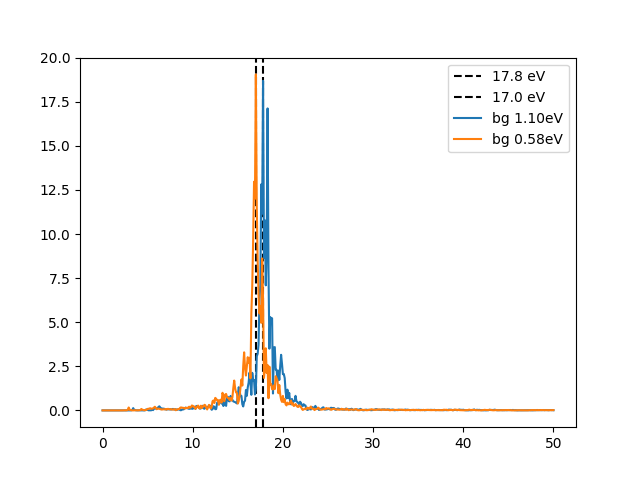

In [33]:
#Testing larger bandgap difference
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_50E_fixbin.npy')
bin_centers = gen_bin_centers(q_max=1)
eps_bg110 = epsilon_r(bin_centers, binned_eps)

binned_eps = np.load('test_resources/binned_eps/binned_eps_bg0.58.npy')
bin_centers = gen_bin_centers(q_max=1)
eps_bg058 = epsilon_r(bin_centers, binned_eps)

q = np.arange(0.01, 1.03, 0.02) #alpha me
E = np.arange(0, 50.1, 0.1) #eV

"""
c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_bg110[np.invert(np.isnan(eps_bg110))]))
re_max = np.max(np.real(eps_bg110[np.invert(np.isnan(eps_bg110))]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2, 2, figsize=(6,6))

im0 = ax[(0,0)].pcolormesh(E, q, np.imag(eps_bg110), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,1)].pcolormesh(E, q, np.real(eps_bg110), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im2 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_bg058), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.real(eps_bg058), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))

ax[(0,0)].set_title(r'RPA Im($\epsilon$), Bandgap = 1.10eV')
ax[(0,1)].set_title(r'Re($\epsilon$), Bandgap = 1.10eV')
ax[(1,0)].set_title(r'RPA Im($\epsilon$), Bandgap = 0.58eV')
ax[(1,1)].set_title(r'Re($\epsilon$), Bandgap = 0.58eV')

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()
"""
plt.figure()
plt.axvline(E[178], color='k', linestyle='--', label=f'{E[178]} eV')
plt.axvline(E[170], color='k', linestyle='--', label=f'{E[170]} eV')
plt.plot(E, elf(eps_bg110)[0], label='bg 1.10eV')
plt.plot(E, elf(eps_bg058)[0], label='bg 0.58eV')
plt.legend()

### Testing Interpolators
- Only LinearNDInterpolator constrains $\text{Im}(\epsilon) > 0$

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:281: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


-4.079971248469738e-17
0.0


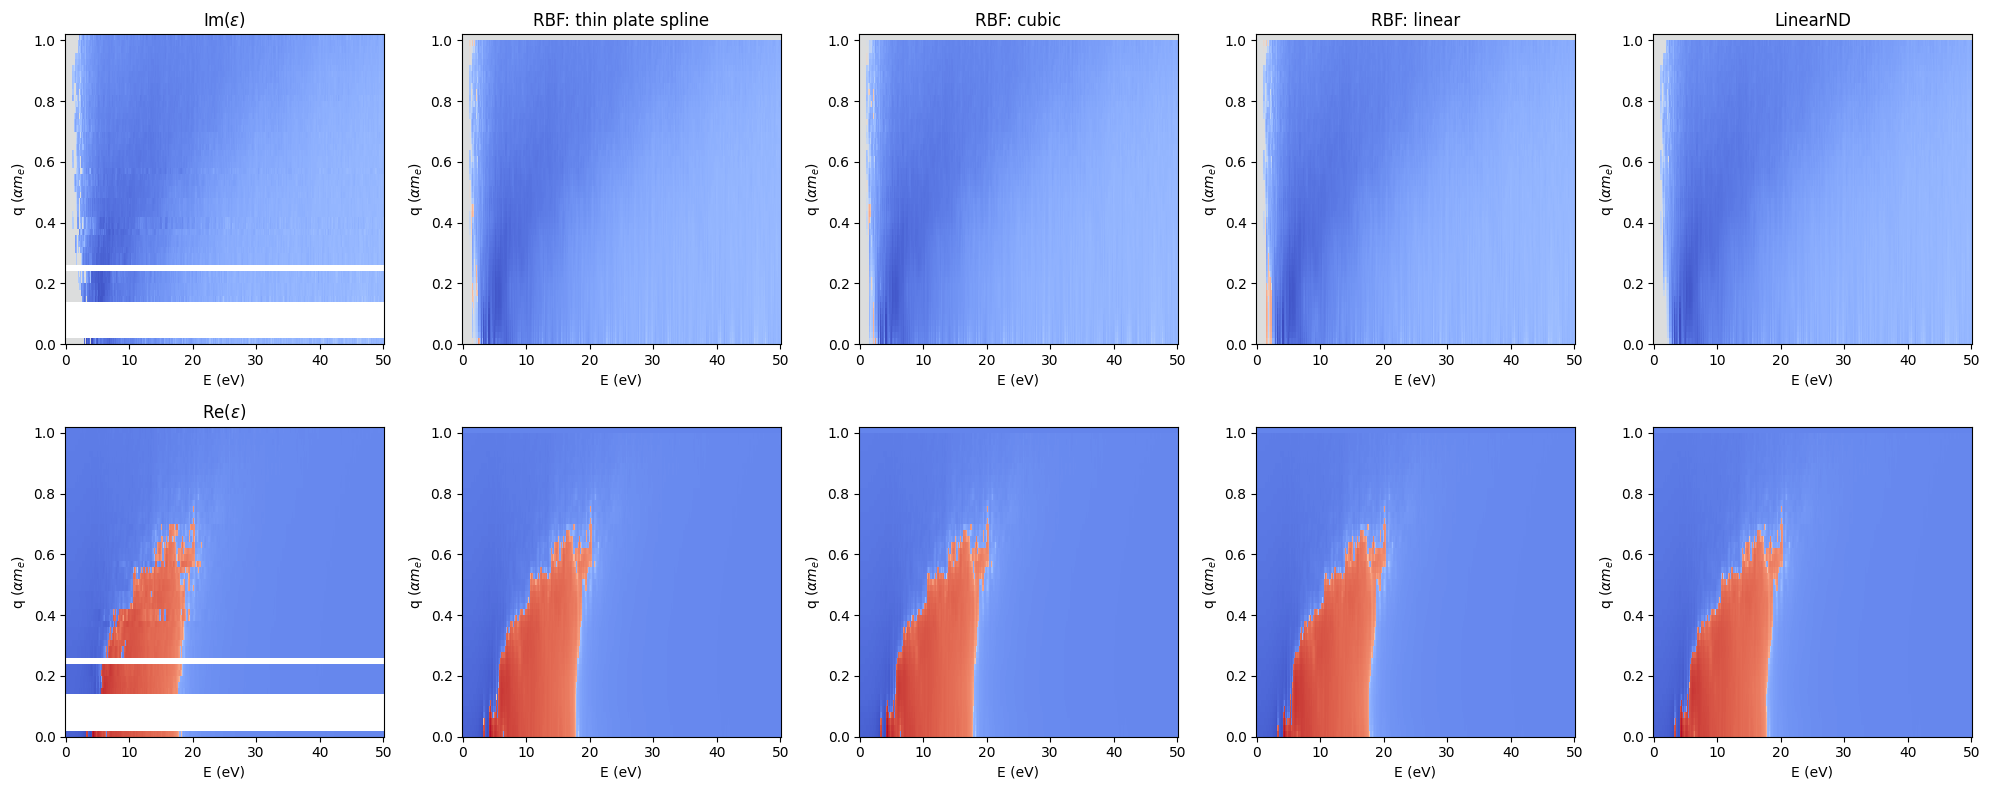

In [1]:
#Interpolation test on 6x6x6
from interp import main
main()

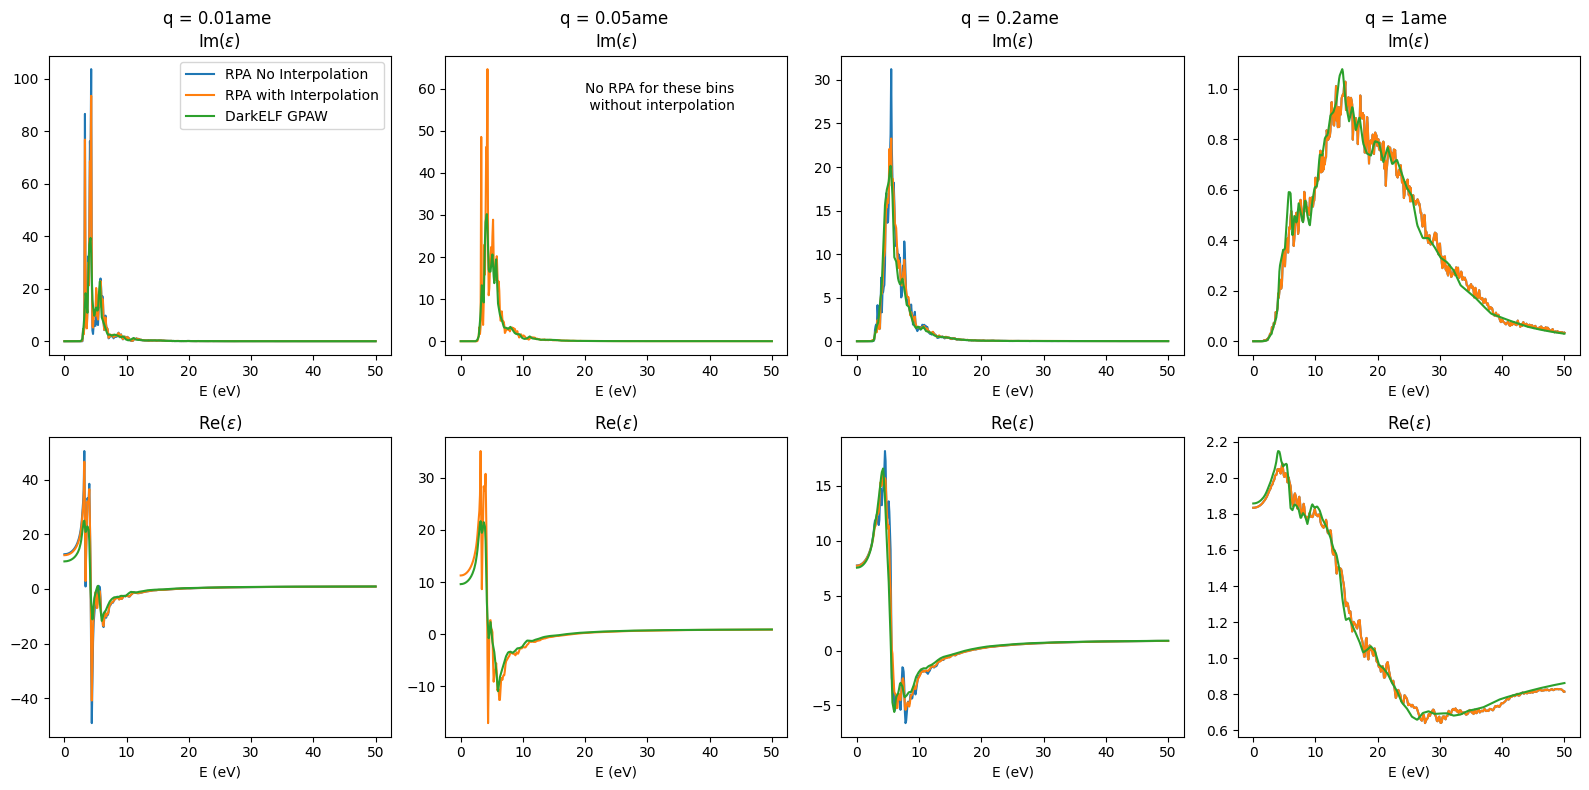

In [7]:
fig, ax = plt.subplots(2,4, figsize=(16,8))

ax[(0,0)].plot(E, np.imag(eps_8)[0,:], label='RPA No Interpolation')
ax[(0,0)].plot(E, np.imag(eps_8_interp)[0,:], label='RPA with Interpolation')
ax[(0,0)].plot(E, darkelf_gpaw.eps2(E, 0.01*alpha*mElectron), label='DarkELF GPAW')
ax[(0,0)].set_title('q = 0.01ame \n'+r'Im($\epsilon$)')
ax[(0,0)].legend()
ax[(1,0)].plot(E, np.real(eps_8)[0,:], label='RPA No Interpolation')
ax[(1,0)].plot(E, np.real(eps_8_interp)[0,:], label='RPA with Interpolation')
ax[(1,0)].plot(E, darkelf_gpaw.eps1(E, 0.01*alpha*mElectron), label='DarkELF GPAW')
ax[(1,0)].set_title(r'Re($\epsilon$)')

ax[(0,1)].plot(E, np.imag(eps_8)[int(0.05/parmt.dq),:], label='RPA No Interpolation')
ax[(0,1)].plot(E, np.imag(eps_8_interp)[int(0.05/parmt.dq),:], label='RPA with Interpolation')
ax[(0,1)].plot(E, darkelf_gpaw.eps2(E, 0.05*alpha*mElectron), label='DarkELF GPAW')
ax[(0,1)].set_title('q = 0.05ame \n'+r'Im($\epsilon$)')
ax[(0,1)].text(20, 55, 'No RPA for these bins \n without interpolation')
ax[(1,1)].plot(E, np.real(eps_8)[int(0.05/parmt.dq),:], label='RPA No Interpolation')
ax[(1,1)].plot(E, np.real(eps_8_interp)[int(0.05/parmt.dq),:], label='RPA with Interpolation')
ax[(1,1)].plot(E, darkelf_gpaw.eps1(E, 0.05*alpha*mElectron), label='DarkELF GPAW')
ax[(1,1)].set_title(r'Re($\epsilon$)')

ax[(0,2)].plot(E, np.imag(eps_8)[int(0.2/parmt.dq),:], label='RPA No Interpolation')
ax[(0,2)].plot(E, np.imag(eps_8_interp)[int(0.2/parmt.dq),:], label='RPA with Interpolation')
ax[(0,2)].plot(E, darkelf_gpaw.eps2(E, 0.2*alpha*mElectron), label='DarkELF GPAW')
ax[(0,2)].set_title('q = 0.2ame \n'+r'Im($\epsilon$)')
ax[(1,2)].plot(E, np.real(eps_8)[int(0.2/parmt.dq),:], label='RPA No Interpolation')
ax[(1,2)].plot(E, np.real(eps_8_interp)[int(0.2/parmt.dq),:], label='RPA with Interpolation')
ax[(1,2)].plot(E, darkelf_gpaw.eps1(E, 0.2*alpha*mElectron), label='DarkELF GPAW')
ax[(1,2)].set_title(r'Re($\epsilon$)')

ax[(0,3)].plot(E, np.imag(eps_8)[-1,:], label='RPA No Interpolation')
ax[(0,3)].plot(E, np.imag(eps_8_interp)[-1,:], label='RPA with Interpolation')
ax[(0,3)].plot(E, darkelf_gpaw.eps2(E, 1*alpha*mElectron), label='DarkELF GPAW')
ax[(0,3)].set_title('q = 1ame \n'+r'Im($\epsilon$)')
ax[(1,3)].plot(E, np.real(eps_8)[-1,:], label='RPA No Interpolation')
ax[(1,3)].plot(E, np.real(eps_8_interp)[-1,:], label='RPA with Interpolation')
ax[(1,3)].plot(E, darkelf_gpaw.eps1(E, 1*alpha*mElectron), label='DarkELF GPAW')
ax[(1,3)].set_title(r'Re($\epsilon$)')

for i in [0,1]:
    for j in [0,1,2,3]:
        ax[(i,j)].set_xlabel('E (eV)')

plt.tight_layout()

### 1/dE Factor

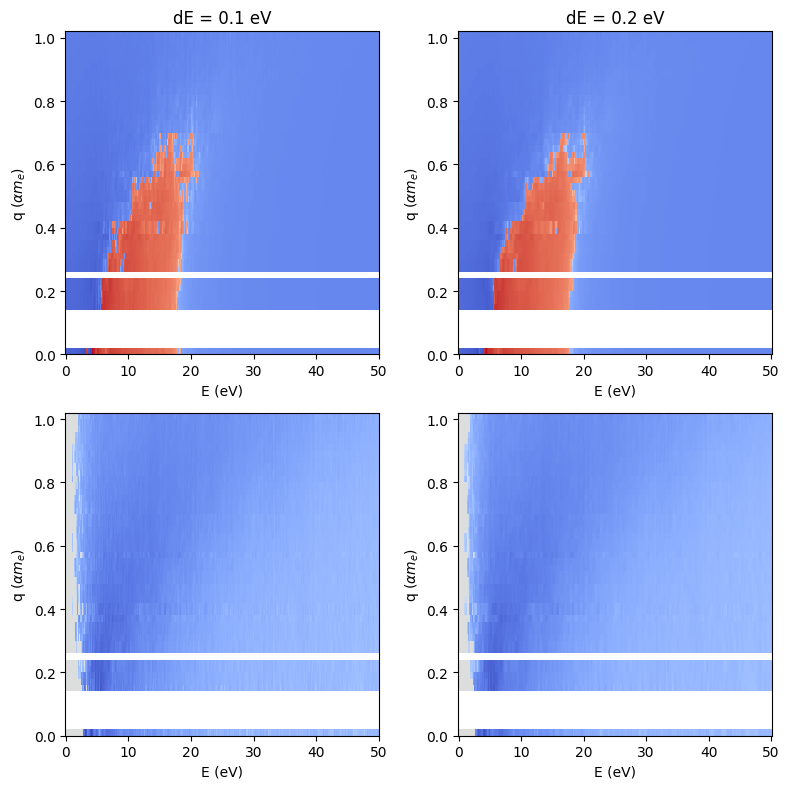

In [11]:
#Testing new code with 1/dE factor - still see same plasmon frequency so we do need this factor!
fig, ax = plt.subplots(2, 2, figsize=(8,8))

#dE = 0.1eV
q = np.arange(0.01, 1+1.5*parmt.dq, parmt.dq) #alpha me
E = np.arange(0, 50+0.1, 0.1) #eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E.npy')
binned_eps = (np.real(binned_eps)-1)*10/4/np.pi+1 + 1j*np.imag(binned_eps)*10/4/np.pi
bin_centers = gen_bin_centers(q_max=1)
eps_1 = epsilon_r(bin_centers, binned_eps)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_1[np.invert(np.isnan(eps_1))]))
re_max = np.max(np.real(eps_1[np.invert(np.isnan(eps_1))]))
im_max = np.max(np.imag(eps_1[np.invert(np.isnan(eps_1))]))
re_max = max(-1*re_min, re_max)

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
ax[(0,0)].set_title('dE = 0.1 eV')

#dE = 0.2eV
E = np.arange(0, 50+0.2, 0.2) #eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E_0.2dE.npy')
bin_centers = gen_bin_centers(q_max=1)
eps_2 = epsilon_r(bin_centers, binned_eps)

im2 = ax[(0,1)].pcolormesh(E, q, np.real(eps_2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.imag(eps_2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
ax[(0,1)].set_title('dE = 0.2 eV')

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

### Fixing $\theta = \pi$ Binning

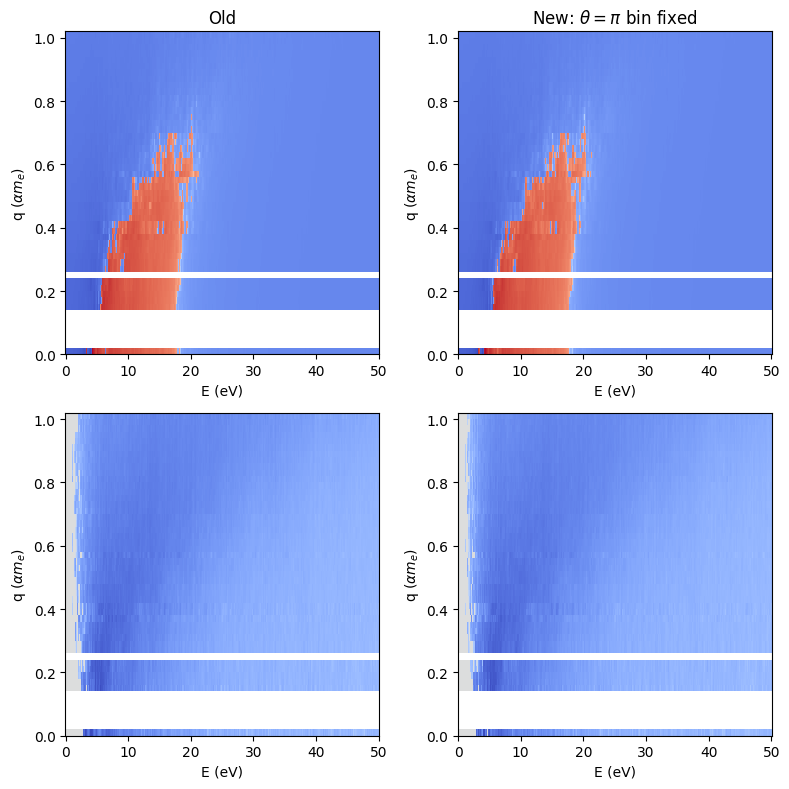

In [12]:
#Fixing theta = pi bin
fig, ax = plt.subplots(2, 2, figsize=(8,8))

#old
q = np.arange(0.01, 1+1.5*parmt.dq, 0.02) #alpha me
E = np.arange(0, 50+0.1, 0.1) #eV
binned_eps_im = 10*np.imag(np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_50E_old.npy'))
binned_eps = kramerskronig_im2re(binned_eps_im) + 1j*binned_eps_im
bin_centers = gen_bin_centers(q_max=1)
eps_1 = epsilon_r(bin_centers, binned_eps)

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_1[np.invert(np.isnan(eps_1))]))
re_max = np.min(np.real(eps_1[np.invert(np.isnan(eps_1))]))
re_max = max(-1*re_min, re_max)

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, np.imag(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
ax[(0,0)].set_title('Old')

#new: binning fixed
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_50E_fixbin.npy')
bin_centers = gen_bin_centers(q_max=1)
eps_2 = epsilon_r(bin_centers, binned_eps)

im2 = ax[(0,1)].pcolormesh(E, q, np.real(eps_2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.imag(eps_2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
ax[(0,1)].set_title(r'New: $\theta = \pi$ bin fixed')

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

### Testing how dE affects noise
For no LFEs:
- Seem to be underestimating $Re(\epsilon)$ near plasmon and underestimating for low energies. 
- Don't think it's an issue with KK functions since KK(GPAW) still looks fine

For LFEs:
- Same problem with $Re(\epsilon)$
- Also overestimates $Im(\epsilon)$ near plasmon

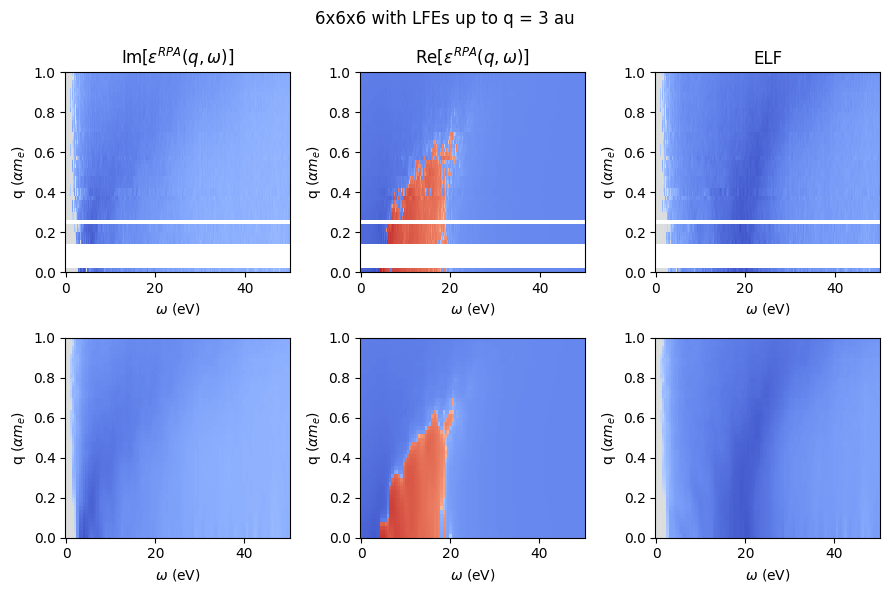

In [11]:
#With LFEs
#dE = 0.1 eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_3q_50E_lfe_neg.npy')
bin_centers = gen_bin_centers(q_max=3)
eps_lfe1 = epsilon_r(bin_centers, binned_eps)
elf_lfe1 = elf(eps_lfe1)

#dE = 0.5 eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6k_bg1.10_dE0.5_lfe.npy')
binned_eps = interp_eps(bin_centers, binned_eps)
eps_lfe5 = epsilon_r(bin_centers, binned_eps)
elf_lfe5 = elf(eps_lfe5)

q = np.arange(0.01,3.03,0.02) #alpha me
E1 = np.linspace(0, 50, 501) #eV
E5 = np.linspace(0, 50, 101) #eV

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_lfe_interp))
re_max = np.max(np.real(eps_lfe_interp))
im_max = np.max(np.imag(eps_lfe_interp))
elf_max = np.max(lfe_interp_elf)
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,3, figsize=(9,6))

im0 = ax[(0,0)].pcolormesh(E1, q, np.imag(eps_lfe1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(0,1)].pcolormesh(E1, q, np.real(eps_lfe1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,2)].pcolormesh(E1, q, elf_lfe1, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))
im0 = ax[(1,0)].pcolormesh(E5, q, np.imag(eps_lfe5), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(1,1)].pcolormesh(E5, q, np.real(eps_lfe5), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,2)].pcolormesh(E5, q, elf_lfe5, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))

ax[(0,0)].set_title(r'Im[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,1)].set_title(r'Re[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,2)].set_title(r'ELF')

for i in [0,1]:
    for j in [0,1,2]:
        #ax[i].set_ylim([0,1])
        ax[(i,j)].set_xlabel(r'$\omega$ (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
        ax[(i,j)].set_ylim((0,1))
fig.suptitle('6x6x6 with LFEs up to q = 3 au')
plt.tight_layout()

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:302: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


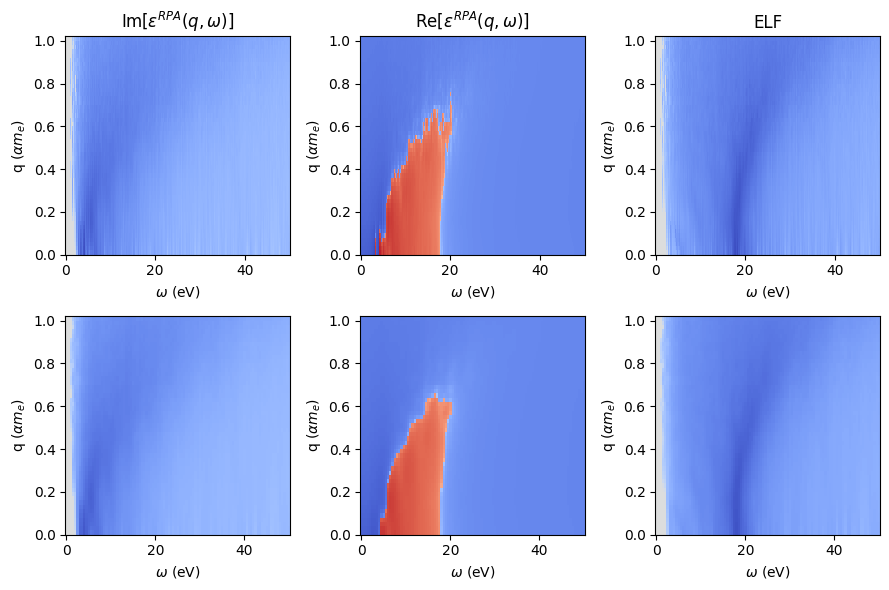

In [4]:
#Without LFEs
#dE = 0.1 eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_1q_50E_fixbin.npy')
bin_centers = gen_bin_centers(q_max=1)
binned_eps = interp_eps(bin_centers, binned_eps)
eps_1 = epsilon_r(bin_centers, binned_eps)
elf_1 = elf(eps_1)

#dE = 0.2 eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.12_1q_50E_0.2dE.npy')
bin_centers = gen_bin_centers(q_max=1)
eps_2 = epsilon_r(bin_centers, binned_eps)
elf_2 = elf(eps_2)

#dE = 0.5 eV
binned_eps = np.load('test_resources/binned_eps/cc-pvtz_pbe_6k_bg1.10_dE0.5.npy')
eps_5 = epsilon_r(bin_centers, binned_eps)
elf_5 = elf(eps_5)

q = np.arange(0.01,1.03,0.02) #alpha me
E1 = np.linspace(0, 50, 501) #eV
E2 = np.arange(0, 50.2, 0.2) #eV
E5 = np.linspace(0, 50, 101) #eV

c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_1))
re_max = np.max(np.real(eps_1))
im_max = np.max(np.imag(eps_1))
elf_max = np.max(elf_1)
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,3, figsize=(9,6))

im0 = ax[(0,0)].pcolormesh(E1, q, np.imag(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(0,1)].pcolormesh(E1, q, np.real(eps_1), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(0,2)].pcolormesh(E1, q, elf_1, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))
im0 = ax[(1,0)].pcolormesh(E5, q, np.imag(eps_5), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
im1 = ax[(1,1)].pcolormesh(E5, q, np.real(eps_5), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,2)].pcolormesh(E5, q, elf_5, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))

ax[(0,0)].set_title(r'Im[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,1)].set_title(r'Re[$\epsilon^{RPA}(q, \omega)$]')
ax[(0,2)].set_title(r'ELF')

for i in [0,1]:
    for j in [0,1,2]:
        #ax[i].set_ylim([0,1])
        ax[(i,j)].set_xlabel(r'$\omega$ (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

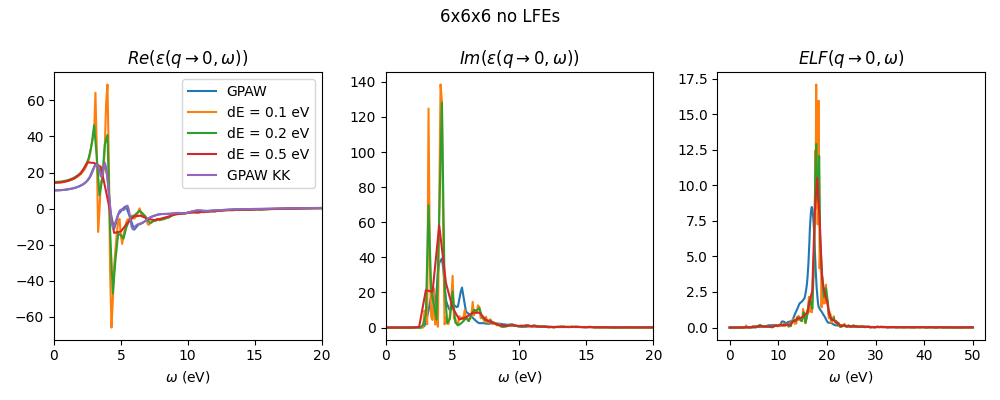

In [8]:
#GPAW
gpaw = darkelf_gpaw.eps1(E1, q*alpha*mElectron) +1j*darkelf_gpaw.eps2(E1, q*alpha*mElectron)
elf_gpaw = elf(gpaw)

gpaw_kk = kramerskronig_im2re(darkelf_gpaw.eps2(E1, q*alpha*mElectron)) + 1

fig, ax = plt.subplots(1,3, figsize=(10,4))
ax[0].plot(E1, np.real(gpaw[0]), label='GPAW')
ax[0].plot(E1, np.real(eps_1[0]), label='dE = 0.1 eV')
ax[0].plot(E2, np.real(eps_2[0]), label='dE = 0.2 eV')
ax[0].plot(E5, np.real(eps_5[0]), label='dE = 0.5 eV')
ax[0].plot(E1, gpaw_kk[0], label='GPAW KK')
ax[0].set_title(r'$Re(\epsilon(q\rightarrow 0, \omega))$')
ax[0].set_xlim((0,20))
ax[0].legend()

ax[1].plot(E1, np.imag(gpaw[0]), label='GPAW')
ax[1].plot(E1, np.imag(eps_1[0]), label='dE = 0.1 eV')
ax[1].plot(E2, np.imag(eps_2[0]), label='dE = 0.2 eV')
ax[1].plot(E5, np.imag(eps_5[0]), label='dE = 0.5 eV')
ax[1].set_title(r'$Im(\epsilon(q\rightarrow 0, \omega))$')
ax[1].set_xlim((0,20))

ax[2].plot(E1, elf_gpaw[0], label='GPAW')
ax[2].plot(E1, elf_1[0], label='dE = 0.1 eV')
ax[2].plot(E2, elf_2[0], label='dE = 0.2 eV')
ax[2].plot(E5, elf_5[0], label='dE = 0.5 eV')
ax[2].set_title(r'$ELF(q\rightarrow 0, \omega)$')

for i in [0,1,2]:
        #ax[i].set_ylim([0,1])
        ax[i].set_xlabel(r'$\omega$ (eV)')
plt.suptitle('6x6x6 no LFEs')
plt.tight_layout()
plt.show()